## Explore and understand data

This section focuses on exploring the data and understanding what the data contain

In [2]:
import pandas as pd

def load_dataset():
    return pd.read_csv(
        "https://raw.githubusercontent.com/emfinne/ML_Assignment1/main/AmesHousing.csv"
    )

df = load_dataset()
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


The dataset contains the first 5 entries with their respective collums in which there are 82. Using the .info member function we can explore the different datatypes included inside the dataset. Additinally we use the .shape member function and see 2930 rows and 82 colums.

In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

(2930, 82)

Looking at the non-null count we see alot of entries is missing such as data row 7 "Alley" with only 198 entries. This means the rest of the entries is either not applicable to have such value assigned or is simple missing.

The dataset contains a range of datatypes such as, int64, float64 and objects. Looking further into what these objects contain by using the .value_counts function, reveal categorical data as text for MS zoning.

In [ ]:
df["MS Zoning"].value_counts()

MS Zoning
RL         2273
RM          462
FV          139
RH           27
C (all)      25
I (all)       2
A (agr)       2
Name: count, dtype: int64

## Cross examening features


Considering the 82 different features each house could have, we could search for data thats not valid across multple features, such as MS SubClass which contain both how many storyes the house contain and build period. Build year is availeble in another collum as is number of storyes.

Since 82 features is alot, developing a scoring system to determen which row may require additional attention enables (fullfør senere)


In [ ]:
df["MS SubClass"].value_counts()


MS SubClass
20     1079
60      575
50      287
120     192
30      139
160     129
70      128
80      118
90      109
190      61
85       48
75       23
45       18
180      17
40        6
150       1
Name: count, dtype: int64

In [ ]:
anomalies = df[
    df["Year_Anomaly"] |
    df["Style_Anomaly"] |
    df["Type_Anomaly"]
]



df["Year_Anomaly"] = (
    (df["MS SubClass"].isin([20, 60]) & (df["Year Built"] < 1946))
    |
    (df["MS SubClass"].isin([30, 70]) & (df["Year Built"] > 1945))
)

df["Style_Anomaly"] = (
    (df["MS SubClass"].isin([20, 30, 40, 120]) & (df["House Style"] != "1Story"))
    |
    (df["MS SubClass"].isin([50, 150]) & (df["House Style"] != "1.5Fin"))
    |
    (df["MS SubClass"].isin([60, 70, 160]) & (df["House Style"] != "2Story"))
    |
    (df["MS SubClass"].isin([80, 180]) & (df["House Style"] != "SLvl"))
    |
    (df["MS SubClass"].isin([85]) & (df["House Style"] != "SFoyer"))
)

df["Type_Anomaly"] = (
    (df["MS SubClass"] == 90) & (df["Bldg Type"] != "Duplex")
)

anomalies[
    ["MS SubClass", "Year Built", "House Style", "Bldg Type",
     "Year_Anomaly", "Style_Anomaly", "Type_Anomaly"]
]




,MS SubClass,Year Built,House Style,Bldg Type,Year_Anomaly,Style_Anomaly,Type_Anomaly
174,50,1915,2Story,1Fam,False,True,False
330,180,1972,SFoyer,TwnhsE,False,True,False
656,60,1939,2Story,1Fam,True,False,False
692,50,1910,2Story,1Fam,False,True,False
731,70,1930,1.5Fin,1Fam,False,True,False
732,30,1916,1.5Unf,1Fam,False,True,False
755,30,1925,1.5Fin,1Fam,False,True,False
886,20,1938,1Story,1Fam,True,False,False
892,180,2005,SFoyer,TwnhsE,False,True,False
955,20,1958,SLvl,1Fam,False,True,False


In [ ]:
print("Year anomalies:", df["Year_Anomaly"].sum())
print("Style anomalies:", df["Style_Anomaly"].sum())
print("Type anomalies:", df["Type_Anomaly"].sum())

Year anomalies: 8
Style anomalies: 34
Type anomalies: 0


In [ ]:
df["Remodel_Anomaly"] = df["Year Remod/Add"] < df["Year Built"]
print("Remodel year anomalies:", df["Remodel_Anomaly"].sum())
df.loc[
    df["Remodel_Anomaly"],
    ["Year Built", "Year Remod/Add"]
]

Remodel year anomalies: 1


,Year Built,Year Remod/Add
850,2002,2001


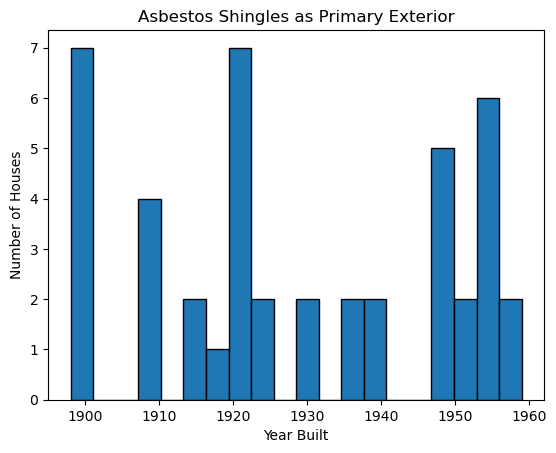

In [ ]:
import matplotlib.pyplot as plt

# Primary exterior = asbestos shingles
primary_asbestos = df[df["Exterior 1st"] == "AsbShng"]

plt.hist(primary_asbestos["Year Built"], bins=20, edgecolor="black")
plt.xlabel("Year Built")
plt.ylabel("Number of Houses")
plt.title("Asbestos Shingles as Primary Exterior")
plt.show()

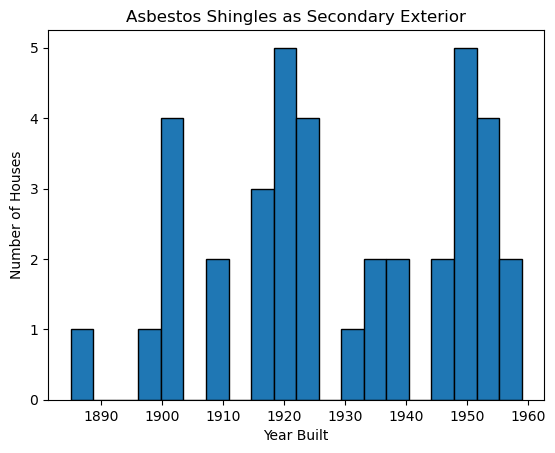

In [ ]:
# Secondary exterior = asbestos shingles
secondary_asbestos = df[df["Exterior 2nd"] == "AsbShng"]

plt.hist(secondary_asbestos["Year Built"], bins=20, edgecolor="black")
plt.xlabel("Year Built")
plt.ylabel("Number of Houses")
plt.title("Asbestos Shingles as Secondary Exterior")
plt.show()

Utilities
AllPub    2927
NoSewr       2
NoSeWa       1
Name: count, dtype: int64